# CardioFusion: o caso clínico

Um paciente de 72 anos, com histórico de doença cardiovascular, chega à UTI com dispneia progressiva, fadiga e edema de membros inferiores. O quadro é de insuficiência cardíaca descompensada, e nas primeiras 24 horas o monitor de cabeceira e o laboratório registram sinais vitais, exames e a escala de coma. Pacientes assim seguem trajetórias muito distintas: alguns estabilizam e recebem alta, outros deterioram e morrem na internação. Identificar cedo quem corre mais risco é a motivação de todo o projeto.

Este notebook procura esse caso dentro da coorte de 1.000 internações e o acompanha nos dados: primeiro o estrato de mesma idade, depois **duas internações reais com perfil quase idêntico na chegada e desfechos opostos**, seguidas hora a hora pela janela de 24h.

## 1 Coorte

Cada internação é um diretório em `data/cohort/cases/`, com dados clínicos, exames e séries de sinais vitais e Glasgow. Aqui carregamos só o essencial: demografia, tipo de admissão e desfecho.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA = Path("../data/cohort/cases")
CASE_AGE = 72  # a idade do paciente do caso clinico

registros = []
for pasta in sorted(p for p in DATA.iterdir() if p.is_dir()):
    dados = json.loads((pasta / "clinical_data.json").read_text())
    registros.append(
        {
            "paciente_id": dados["paciente_id"],
            "idade": dados["demografia"]["idade"],
            "sexo": dados["demografia"]["sexo"],
            "tipo_admissao": dados["admissao"]["tipo"],
            "obito_hospitalar": bool(dados["admissao"]["obito_hospitalar"]),
        }
    )
cohort = pd.DataFrame(registros)


def read_series(pid, name):
    """Le uma serie temporal do caso, ordenada pela hora na janela; vazia se nao existir."""
    path = DATA / pid / name
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path).sort_values("horas_da_janela")


print(f"internações: {len(cohort)}")
print(
    f"óbitos hospitalares: {cohort.obito_hospitalar.sum()} ({cohort.obito_hospitalar.mean():.1%})"
)
print(f"idade mediana: {cohort.idade.median():.0f} anos")

internações: 1000
óbitos hospitalares: 165 (16.5%)
idade mediana: 74 anos


## 2 O paciente do caso na coorte

O caso fixa uma idade: 72 anos. Antes de procurar um paciente concreto, vale situar essa idade na distribuição da coorte e medir a mortalidade do estrato.

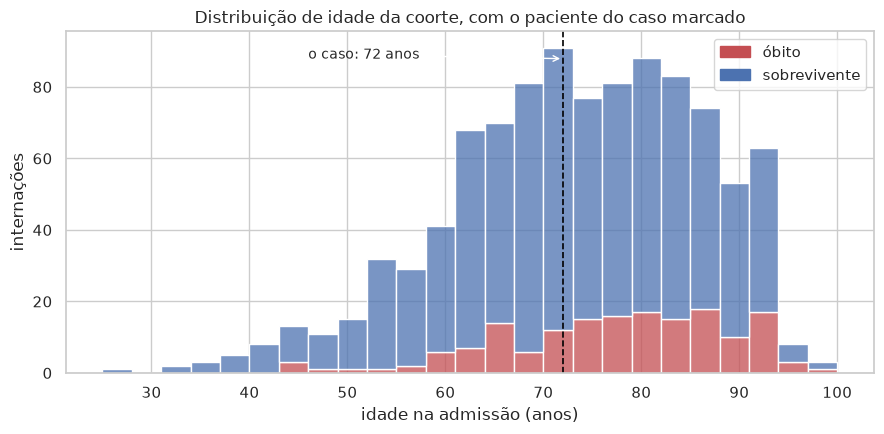

idade exatamente 72: 30 internações, 4 óbitos (13.3%)
faixa 70 a 74: 138 internações, 18 óbitos (13.0%)


In [2]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(
    data=cohort,
    x="idade",
    hue="obito_hospitalar",
    bins=range(25, 101, 3),
    multiple="stack",
    palette={False: "#4c72b0", True: "#c44e52"},
    ax=ax,
)
ax.axvline(CASE_AGE, color="black", linestyle="--", linewidth=1.2)
ax.annotate(
    f"o caso: {CASE_AGE} anos",
    xy=(CASE_AGE, ax.get_ylim()[1] * 0.92),
    xytext=(CASE_AGE - 26, ax.get_ylim()[1] * 0.92),
    fontsize=10,
    arrowprops={"arrowstyle": "->"},
)
ax.set_xlabel("idade na admissão (anos)")
ax.set_ylabel("internações")
ax.set_title("Distribuição de idade da coorte, com o paciente do caso marcado")
ax.legend(
    handles=[
        plt.matplotlib.patches.Patch(color="#c44e52", label="óbito"),
        plt.matplotlib.patches.Patch(color="#4c72b0", label="sobrevivente"),
    ]
)
plt.tight_layout()
plt.show()

exact = cohort[cohort.idade == CASE_AGE]
band = cohort[cohort.idade.between(CASE_AGE - 2, CASE_AGE + 2)]
print(
    f"idade exatamente {CASE_AGE}: {len(exact)} internações, "
    f"{exact.obito_hospitalar.sum()} óbitos ({exact.obito_hospitalar.mean():.1%})"
)
print(
    f"faixa {CASE_AGE - 2} a {CASE_AGE + 2}: {len(band)} internações, "
    f"{band.obito_hospitalar.sum()} óbitos ({band.obito_hospitalar.mean():.1%})"
)

> **Interpretação.** O paciente do caso não é raro nem extremo: 72 anos fica logo abaixo da mediana da coorte (74), e há 30 internações com exatamente essa idade, 138 na faixa de 70 a 74. A mortalidade do estrato (13,3% na idade exata, 13,0% na faixa) é próxima da mortalidade geral de 16,5%. Ou seja, a idade sozinha não conta a história: dentro do mesmo estrato etário, uns morrem e outros não, que é exatamente a situação que o caso descreve e que o projeto quer explicar.

## 3 Dois pacientes, uma chegada

O centro do caso é a frase "pacientes parecidos na admissão evoluem de formas muito diferentes". Para vê-la nos dados, procuramos **o par mais parecido possível**: entre as internações de 72 anos, um óbito e um sobrevivente do mesmo sexo cujos primeiros sinais vitais na UTI sejam os mais próximos, pela distância euclidiana entre frequência cardíaca e pressão sistólica iniciais. Internações sem uma das duas medidas na chegada ficam fora do pareamento. O critério é declarado antes de olhar o resultado, para que a escolha seja reproduzível e não uma seleção conveniente.

In [3]:
profile = cohort[cohort.idade == CASE_AGE]

# primeiro valor de cada sinal vital por internacao do estrato
first_vitals = {}
for pid in profile.paciente_id:
    vit = read_series(pid, "vitals_series.csv")
    if not vit.empty:
        first_vitals[pid] = vit.groupby("sinal").valor.first()
first_vitals = pd.DataFrame(first_vitals).T

deaths = profile[profile.obito_hospitalar].paciente_id
survivors = profile[~profile.obito_hospitalar].paciente_id
sex = profile.set_index("paciente_id").sexo

pairs = []
for dead in deaths:
    for alive in survivors:
        if sex[dead] != sex[alive]:
            continue
        delta = first_vitals.loc[[dead, alive], ["Heart Rate", "Systolic BP"]].diff().iloc[-1]
        dist = float(np.sqrt((delta**2).sum(skipna=False)))  # exige os dois sinais na chegada
        if not np.isnan(dist):
            pairs.append({"obito": dead, "sobrevivente": alive, "dist": dist})
pairs = pd.DataFrame(pairs).sort_values("dist")
pair = pairs.iloc[0]
DEAD, ALIVE = pair.obito, pair.sobrevivente
print(f"par selecionado: {DEAD} (óbito) e {ALIVE} (sobrevivente), distância {pair.dist:.1f}")

# quadro comparativo da chegada: sinais vitais, primeiro painel de exames e primeiro Glasgow
LABS = ["Urea Nitrogen", "Creatinine", "Anion Gap", "Bicarbonate", "Lactate"]


def admission_row(pid):
    info = cohort.set_index("paciente_id").loc[pid]
    row = {"idade": info.idade, "sexo": info.sexo, "tipo de admissão": info.tipo_admissao}
    for sig in ["Heart Rate", "Systolic BP", "Respiratory Rate", "SpO2", "Temperature"]:
        row[sig] = round(first_vitals.loc[pid, sig], 1)
    lab = pd.read_csv(DATA / pid / "laboratory.csv").set_index("exame")
    for exame in LABS:
        row[exame] = "não solicitado" if lab.loc[exame, "ausente"] else lab.loc[exame, "valor"]
    gcs = read_series(pid, "gcs_series.csv")
    row["primeiro GCS total"] = gcs["GCS total"].iloc[0] if not gcs.empty else np.nan
    return pd.Series(row)


pd.DataFrame(
    {f"{DEAD} (óbito)": admission_row(DEAD), f"{ALIVE} (sobrevivente)": admission_row(ALIVE)}
)

par selecionado: case_0868 (óbito) e case_0108 (sobrevivente), distância 9.1


,case_0868 (óbito),case_0108 (sobrevivente)
idade,72,72
sexo,M,M
tipo de admissão,OBSERVATION ADMIT,EW EMER.
Heart Rate,96.0,87.0
Systolic BP,109.0,110.0
Respiratory Rate,21.0,18.0
SpO2,98.0,96.0
Temperature,36.7,36.7
Urea Nitrogen,22.0,54.0
Creatinine,0.8,1.0


> **Interpretação.** Na chegada, os dois são quase o mesmo paciente: homens de 72 anos, frequência cardíaca de 96 contra 87, pressão sistólica de 109 contra 110, saturação de 98% contra 96%, temperatura idêntica de 36,7 °C. O primeiro painel de sangue de quem morreu era quase normal: creatinina 0,8, ânion gap 15, bicarbonato 25, ureia 22. A ureia do sobrevivente, 54, era mais que o dobro, e acima do corte de 43 mg/dL do ADHERE, ou seja, **um marcador estático isolado apontaria o paciente errado**. Dois detalhes destoam: quem morreu entrou como admissão para observação, sem a etiqueta de emergência, e seu lactato inicial de 7,3 mmol/L era o único exame a denunciar a gravidade, além do primeiro Glasgow, já em 3 na quinta hora. A deterioração tinha começado antes de os sinais clássicos se moverem.

## 4 As 24 horas lado a lado: sinais vitais

A mesma janela, hora a hora, para os dois pacientes.

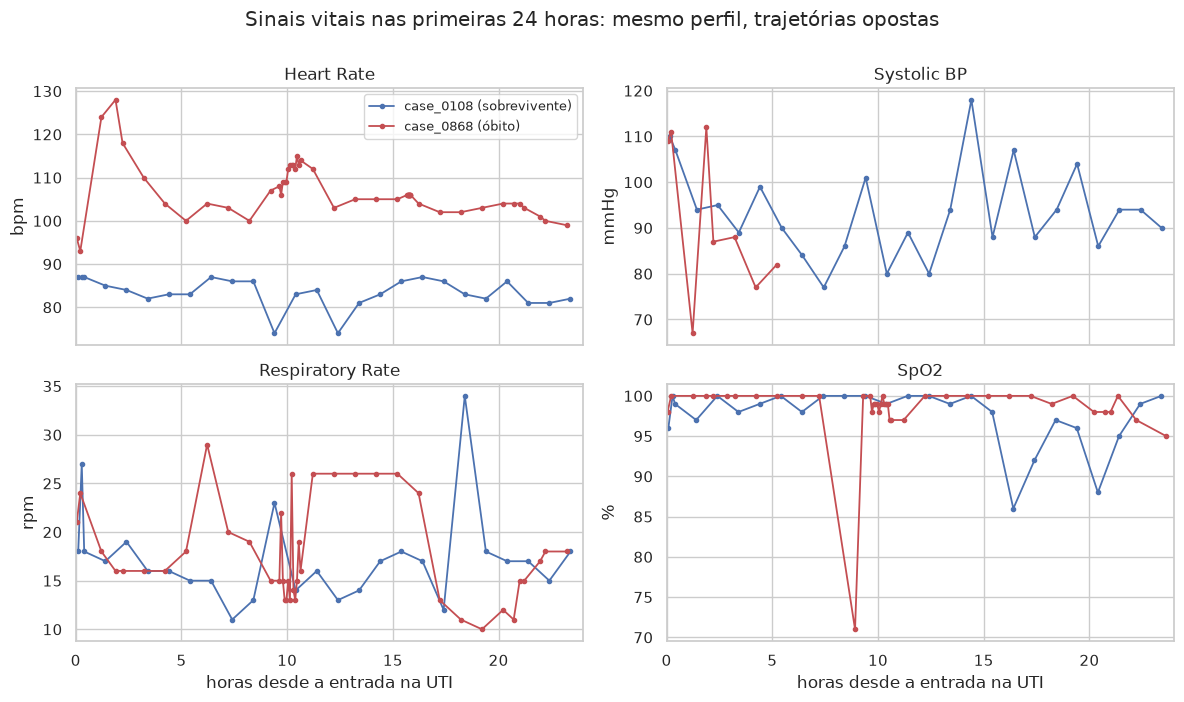

In [4]:
COLORS = {DEAD: "#c44e52", ALIVE: "#4c72b0"}
LABELS = {DEAD: f"{DEAD} (óbito)", ALIVE: f"{ALIVE} (sobrevivente)"}
SIGNALS = [
    ("Heart Rate", "bpm"),
    ("Systolic BP", "mmHg"),
    ("Respiratory Rate", "rpm"),
    ("SpO2", "%"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, (sig, unit) in zip(axes.flat, SIGNALS, strict=False):
    for pid in (ALIVE, DEAD):
        vit = read_series(pid, "vitals_series.csv")
        serie = vit[vit.sinal == sig]
        ax.plot(
            serie.horas_da_janela,
            serie.valor,
            marker="o",
            markersize=3,
            linewidth=1.3,
            color=COLORS[pid],
            label=LABELS[pid],
        )
    ax.set_title(sig)
    ax.set_ylabel(unit)
    ax.set_xlim(0, 24)
for ax in axes[1]:
    ax.set_xlabel("horas desde a entrada na UTI")
axes[0, 0].legend(fontsize=9)
fig.suptitle("Sinais vitais nas primeiras 24 horas: mesmo perfil, trajetórias opostas", y=1.0)
plt.tight_layout()
plt.show()

> **Interpretação.** As curvas contam o que a chegada escondia. No óbito, a saturação despenca até 71% e a pressão sistólica até 67 mmHg, com a frequência cardíaca subindo a 128 bpm. Mas a leitura honesta exige notar que o sobrevivente também tem mínimos ruins: pressão em 77 mmHg e saturação em 86% em algum momento da janela. A diferença não está em um valor isolado cruzar um limiar, e sim no conjunto: no óbito, os extremos chegam juntos, se sustentam e vêm acompanhados de lactato alto e coma, enquanto no sobrevivente são quedas transitórias que revertem. É um argumento visual para os biomarcadores dinâmicos e para a análise multivariada, contra a leitura de um sinal de cada vez.

## 5 O laboratório na janela

Os exames seriados dos dois pacientes: função renal, equilíbrio ácido-base e lactato.

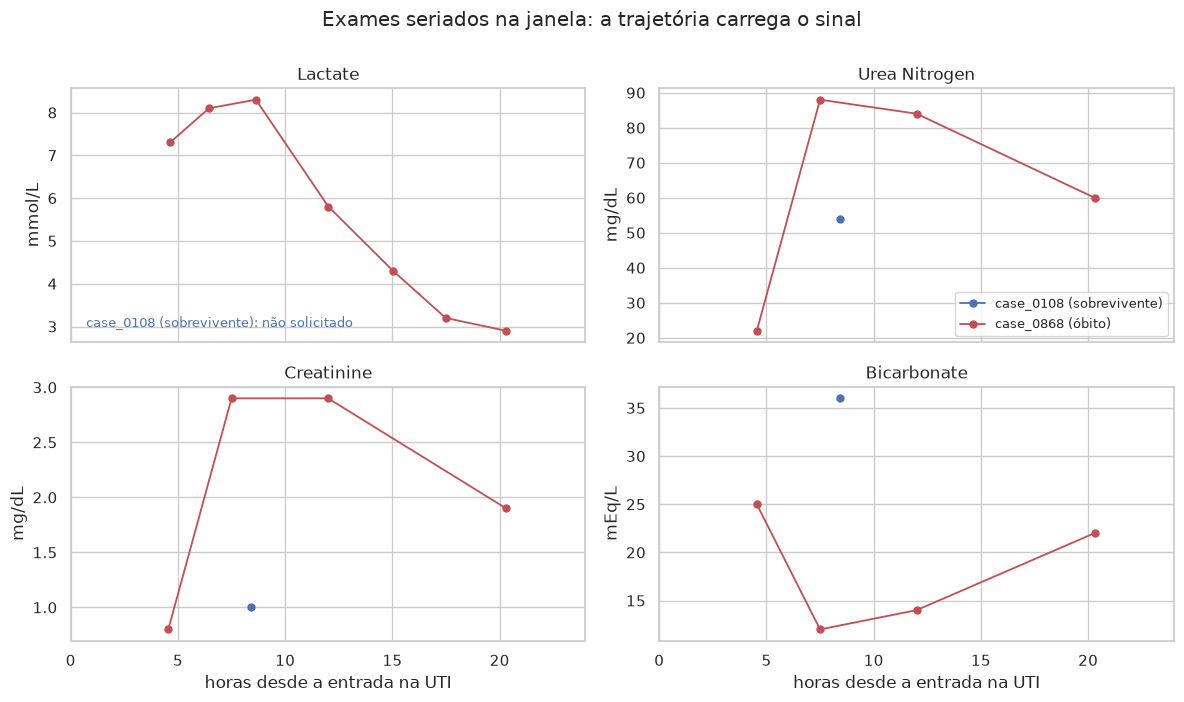

In [5]:
EXAMS = [
    ("Lactate", "mmol/L"),
    ("Urea Nitrogen", "mg/dL"),
    ("Creatinine", "mg/dL"),
    ("Bicarbonate", "mEq/L"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, (exam, unit) in zip(axes.flat, EXAMS, strict=False):
    for pid in (ALIVE, DEAD):
        lab = read_series(pid, "laboratory_series.csv")
        serie = lab[lab.exame == exam] if not lab.empty else lab
        if serie.empty:
            ax.annotate(
                f"{LABELS[pid]}: não solicitado",
                xy=(0.03, 0.06),
                xycoords="axes fraction",
                fontsize=9,
                color=COLORS[pid],
            )
            continue
        ax.plot(
            serie.horas_da_janela,
            serie.valor,
            marker="o",
            markersize=5,
            linewidth=1.3,
            color=COLORS[pid],
            label=LABELS[pid],
        )
    ax.set_title(exam)
    ax.set_ylabel(unit)
    ax.set_xlim(0, 24)
for ax in axes[1]:
    ax.set_xlabel("horas desde a entrada na UTI")
axes[0, 1].legend(fontsize=9)
fig.suptitle("Exames seriados na janela: a trajetória carrega o sinal", y=1.0)
plt.tight_layout()
plt.show()

> **Interpretação.** Duas lições em um gráfico. Primeiro, a trajetória corrige o valor de admissão: a ureia do óbito vai de 22 a 88 mg/dL em três horas e a creatinina de 0,8 a 2,9, uma lesão renal aguda se instalando dentro da janela, enquanto o bicarbonato cai de 25 a 12. O sobrevivente, com sua ureia estática de 54, tem um único painel colhido às 8,4 horas e nada mais. Segundo, a ausência é informativa na prática: foram sete lactatos no paciente que deteriorava e **nenhum** no que estava estável. A própria decisão de repetir exames marca a gravidade percebida pela equipe, o mecanismo MNAR discutido no notebook 01. O clearance parcial do lactato (de 8,3 a 2,9) mostra ainda que a resposta ao tratamento também fica registrada na janela.

## 6 A consciência: escala de Glasgow

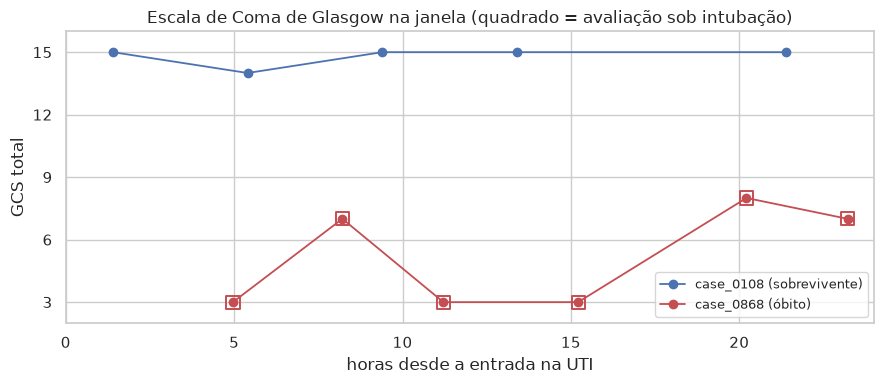

case_0868: 6 avaliações, todas sob intubação: True


In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
for pid in (ALIVE, DEAD):
    gcs = read_series(pid, "gcs_series.csv")
    ax.plot(
        gcs.horas_da_janela,
        gcs["GCS total"],
        marker="o",
        markersize=6,
        linewidth=1.3,
        color=COLORS[pid],
        label=LABELS[pid],
    )
    intub = gcs[gcs.verbal_intubado]
    ax.scatter(
        intub.horas_da_janela,
        intub["GCS total"],
        marker="s",
        s=90,
        facecolors="none",
        edgecolors=COLORS[pid],
        linewidths=1.4,
    )
ax.set_xlim(0, 24)
ax.set_ylim(2, 16)
ax.set_yticks([3, 6, 9, 12, 15])
ax.set_xlabel("horas desde a entrada na UTI")
ax.set_ylabel("GCS total")
ax.set_title("Escala de Coma de Glasgow na janela (quadrado = avaliação sob intubação)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

gcs_dead = read_series(DEAD, "gcs_series.csv")
print(f"{DEAD}: {len(gcs_dead)} avaliações, todas sob intubação: {gcs_dead.verbal_intubado.all()}")

> **Interpretação.** O sobrevivente permanece em 15, o topo da escala, a janela inteira, com uma única oscilação a 14. O óbito nunca é avaliado acordado: a primeira medida, às 5 horas, já o encontra intubado e com escore 3, e todas as seis avaliações da janela carregam a marcação de intubação. Vale a ressalva metodológica do notebook 01: sob intubação a resposta verbal pontua 1 por impossibilidade de falar, o que rebaixa o total mesmo em paciente sedado, então o 3 mistura gravidade real com artefato de medida. Ainda assim, o contraste é eloquente: em cinco horas, um paciente que chegou com sinais vitais de rotina estava em ventilação mecânica.

## 7 Chegada contra janela

O resumo do par em uma tabela: o valor de admissão de cada variável ao lado do pior valor alcançado nas 24 horas.

In [7]:
WORST = {  # sentido do "pior" para cada variavel
    "Heart Rate": "max",
    "Systolic BP": "min",
    "Respiratory Rate": "max",
    "SpO2": "min",
    "GCS total": "min",
    "Urea Nitrogen": "max",
    "Creatinine": "max",
    "Bicarbonate": "min",
    "Lactate": "max",
}


def arrival_vs_window(pid):
    vit = read_series(pid, "vitals_series.csv")
    lab = read_series(pid, "laboratory_series.csv")
    gcs = read_series(pid, "gcs_series.csv")
    rows = {}
    for var, side in WORST.items():
        if var == "GCS total":
            serie = gcs["GCS total"] if not gcs.empty else pd.Series(dtype=float)
        elif var in set(vit.sinal):
            serie = vit.loc[vit.sinal == var, "valor"]
        else:
            serie = lab.loc[lab.exame == var, "valor"] if not lab.empty else pd.Series(dtype=float)
        if serie.empty:
            rows[var] = ("não solicitado", "não solicitado")
        else:
            rows[var] = (serie.iloc[0], serie.min() if side == "min" else serie.max())
    return rows


table = {}
for pid in (DEAD, ALIVE):
    rows = arrival_vs_window(pid)
    who = "óbito" if pid == DEAD else "sobrevivente"
    table[(who, "chegada")] = {k: v[0] for k, v in rows.items()}
    table[(who, "pior da janela")] = {k: v[1] for k, v in rows.items()}
pd.DataFrame(table).loc[list(WORST)]

óbito                   sobrevivente                
                 chegada pior da janela         chegada  pior da janela
Heart Rate          96.0          128.0            87.0            87.0
Systolic BP        109.0           67.0           110.0            77.0
Respiratory Rate    21.0           29.0            18.0            34.0
SpO2                98.0           71.0            96.0            86.0
GCS total            3.0            3.0            15.0            14.0
Urea Nitrogen       22.0           88.0            54.0            54.0
Creatinine           0.8            2.9             1.0             1.0
Bicarbonate         25.0           12.0            36.0            36.0
Lactate              7.3            8.3  não solicitado  não solicitado

> **Interpretação.** A coluna de chegada confunde: lida sozinha, ela aponta risco maior no sobrevivente, que tinha ureia acima do corte da literatura. As colunas do pior da janela separam os dois por completo: Glasgow 3 contra 14, bicarbonato 12 contra 36, ureia 88 contra 54, lactato 8,3 contra exame nunca solicitado. É o caso clínico do enunciado traduzido em números, e o motivo de o quadro de candidatos da Entrega 1 incluir, além dos valores de admissão, as leituras dinâmicas da janela (candidato K): valor inicial, extremos, tendência.